# Job Market Intelligence Pipeline Analysis

This notebook explores cleaned job listing data to identify patterns in skill demand, job locations, remote work distribution, and salary availability.

The aim of this project is to transform raw web-based job listing data into a structured dataset that can be analyzed for useful job market insights.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

df = pd.read_csv("../data/cleaned_jobs.csv")
df.head()

,title,company,location,location_clean,work_type,salary,salary_min_num,salary_max_num,salary_mid,salary_valid,skills,skills_clean,technical_skills_detected,descriptive_tags_detected,date_posted,scraped_at,source
0,Full Stack Developer,ELECTE S.R.L,Unknown,Unknown,Unknown,30000 - 50000,30000.0,50000.0,40000.0,True,"engineer, javascript, typescript, python, Full...","ai, engineer, full-stack, javascript, postgres...","java, javascript, python, r, typescript","engineer, full stack, full-stack",2026-03-13T12:15:25+00:00,2026-03-14 14:23:15,https://remoteOK.com/remote-jobs/remote-full-s...
1,Entry Level Crypto Market Specialist,ELEMENTAL TERRA,Unknown,Unknown,Unknown,50000 - 70000,50000.0,70000.0,60000.0,True,"other, crypto, finance, web3, blockchain, defi...","bitcoin, blockchain, crypto, defi, education, ...",r,NaN,2026-03-13T08:23:00+00:00,2026-03-14 14:23:15,https://remoteOK.com/remote-jobs/remote-entry-...
2,Senior Developer Experience Engineer,Galaxy,Unknown,Unknown,Unknown,Not Provided,NaN,NaN,NaN,False,"developer, web3, crypto, founder, ceo, investm...","ceo, crypto, developer, digital nomad, enginee...","git, r","digital nomad, engineer, engineering, founder,...",2026-03-13T08:00:37+00:00,2026-03-14 14:23:15,https://remoteOK.com/remote-jobs/remote-senior...
3,Cloud Security Architect,Altium,La Jolla,La Jolla,Location-Specific,Not Provided,NaN,NaN,NaN,False,"security, architect, design, saas, system, sof...","architect, cloud, design, digital nomad, engin...","git, r","design, digital nomad, engineer, engineering, ...",2026-03-13T08:00:11+00:00,2026-03-14 14:23:15,https://remoteOK.com/remote-jobs/remote-cloud-...
4,Go To Market Strategist AI Trainer Freelance 8...,10x Team,London,London,Location-Specific,80 - 140,NaN,NaN,NaN,False,"trainer, strategist, content, marketing, sales...","content, go, marketing, non tech, sales, strat...",r,marketing,2026-03-13T08:00:09+00:00,2026-03-14 14:23:15,https://remoteOK.com/remote-jobs/remote-go-to-...


In [2]:
print(df.columns.tolist())

['title', 'company', 'location', 'location_clean', 'work_type', 'salary', 'salary_min_num', 'salary_max_num', 'salary_mid', 'salary_valid', 'skills', 'skills_clean', 'technical_skills_detected', 'descriptive_tags_detected', 'date_posted', 'scraped_at', 'source']


## Dataset Overview

Before performing analysis, it is important to understand the structure of the dataset, the number of rows and columns, and whether there are missing values in important fields.

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   title                      99 non-null     str    
 1   company                    99 non-null     str    
 2   location                   99 non-null     str    
 3   location_clean             99 non-null     str    
 4   work_type                  99 non-null     str    
 5   salary                     99 non-null     str    
 6   salary_min_num             8 non-null      float64
 7   salary_max_num             8 non-null      float64
 8   salary_mid                 8 non-null      float64
 9   salary_valid               99 non-null     bool   
 10  skills                     97 non-null     str    
 11  skills_clean               97 non-null     str    
 12  technical_skills_detected  97 non-null     str    
 13  descriptive_tags_detected  93 non-null     str    
 14  date_po

In [4]:
df.describe(include="all")

,title,company,location,location_clean,work_type,salary,salary_min_num,salary_max_num,salary_mid,salary_valid,skills,skills_clean,technical_skills_detected,descriptive_tags_detected,date_posted,scraped_at,source
count,99,99,99,99,99,99,8.000000,8.000000,8.000000,99,97,97,97,93,99,99,99
unique,99,89,37,31,3,10,NaN,NaN,NaN,2,96,96,17,82,98,1,99
top,Full Stack Developer,Eleventh Hour Games,Unknown,Unknown,Unknown,Not Provided,NaN,NaN,NaN,False,"golang, software, cloud, senior, engineer","cloud, engineer, golang, senior, software",r,support,2026-03-12T13:00:02+00:00,2026-03-14 14:23:15,https://remoteOK.com/remote-jobs/remote-full-s...
freq,1,6,41,41,41,88,NaN,NaN,NaN,91,2,2,56,5,2,99,1
mean,NaN,NaN,NaN,NaN,NaN,NaN,47125.000000,63250.000000,55187.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,16999.474782,19031.928061,17864.444936,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,30000.000000,50000.000000,40000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,37500.000000,50000.000000,43750.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,41000.000000,51000.000000,46000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,55000.000000,75000.000000,65000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Interpretation

The dataset contains job listing information such as title, company, location, salary, skills, posting date, and cleaned fields created during preprocessing.

Several columns contain missing or inconsistent values, especially salary-related fields. This reflects the messy nature of real-world web data and shows why the cleaning stage is important.

## Top Skills

This section identifies the most frequently occurring tags or skills found in the cleaned dataset.

In [5]:
technical_series = df["technical_skills_detected"].replace("", pd.NA).dropna().str.split(", ")
technical_exploded = technical_series.explode()
top_technical_skills = technical_exploded.value_counts().head(10)

top_technical_skills

technical_skills_detected
r             97
git           33
api            8
python         7
linux          4
java           3
javascript     3
react          3
node           2
sql            2
Name: count, dtype: int64

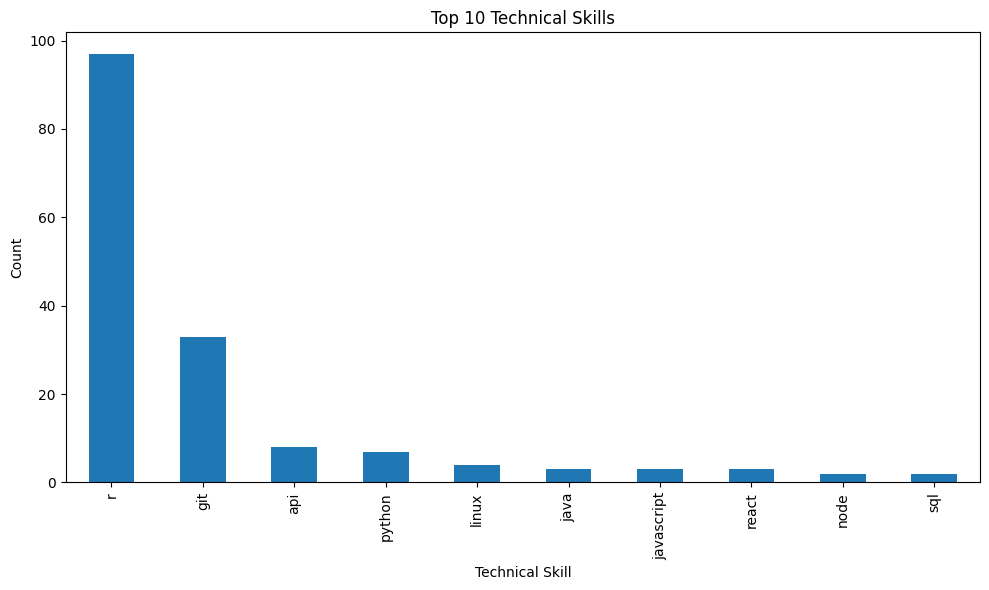

In [6]:
plt.figure(figsize=(10, 6))
top_technical_skills.plot(kind="bar")
plt.title("Top 10 Technical Skills")
plt.xlabel("Technical Skill")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../outputs/top_skills.png")
plt.show()

### Interpretation

The most common extracted tags include both technical and descriptive keywords. This suggests that the source data mixes true technical skills with broader job descriptors.

This is a useful finding because it highlights a common data quality issue in job listing data. In a future version, skill classification could be improved by using a controlled skill dictionary or NLP-based text processing.

## Top Locations

This section examines which locations appear most often in the job listings dataset.

In [7]:
top_locations = df["location_clean"].value_counts().head(10)
top_locations

location_clean
Unknown            41
Global Remote      10
United States      10
US Remote           5
Other Remote        5
London              3
La Jolla            1
Port-Au-Prince      1
Brazil              1
Boston, Ma, Usa     1
Name: count, dtype: int64

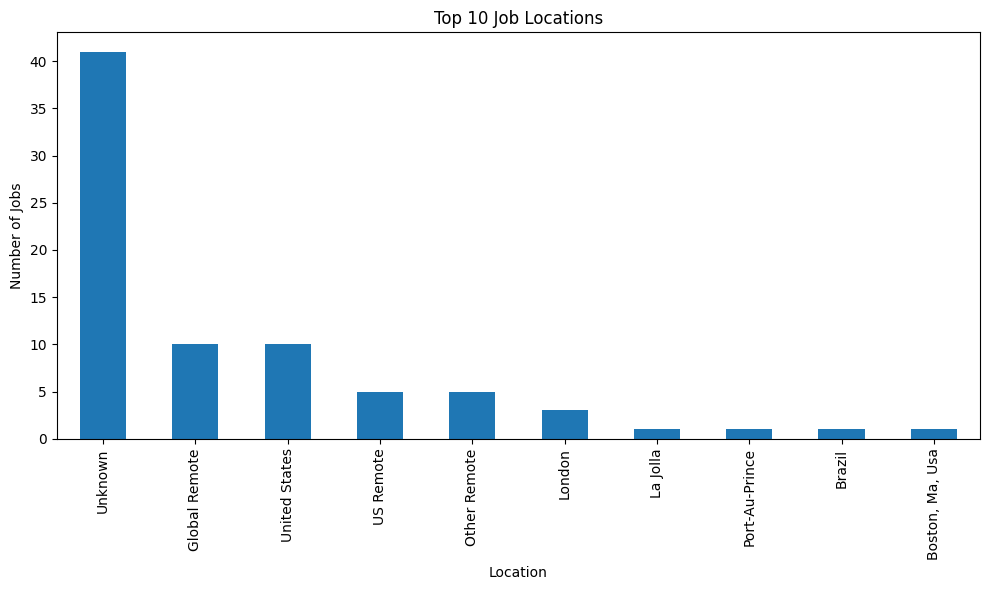

In [8]:
plt.figure(figsize=(10, 6))
top_locations.plot(kind="bar")
plt.title("Top 10 Job Locations")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.savefig("../outputs/jobs_by_city.png")
plt.show()

### Interpretation

A large number of listings were labelled as remote or not specified, which indicates that location data is not always standardized in online job postings.

This shows that even when location information exists, it often requires additional cleaning before it can support more detailed geographic analysis.

## Remote vs Region-Specific Remote

This section compares fully remote roles with roles that are remote but restricted to a region or country.

In [9]:
work_counts = df["work_type"].value_counts()
work_counts

work_type
Unknown              41
Location-Specific    38
Remote               20
Name: count, dtype: int64

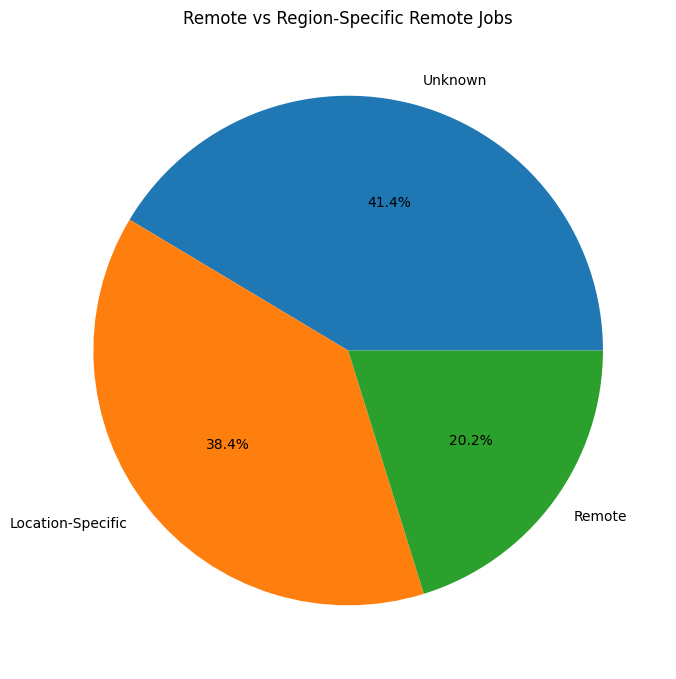

In [10]:
plt.figure(figsize=(7, 7))
work_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Remote vs Region-Specific Remote Jobs")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../outputs/remote_vs_nonremote.png")
plt.show()

### Interpretation

The dataset shows that fully remote roles make up the majority of listings, while a smaller share are region-specific remote roles.

This suggests that although remote work is common in the dataset, it is not always globally flexible. Some employers still place geographic restrictions on remote hiring.

## Key Skill Mentions

This section focuses on four commonly requested data-related skills: Python, SQL, Excel, and Power BI.

In [11]:
for skill in ["Python", "SQL", "Excel", "Power BI"]:
    count = df["technical_skills_detected"].fillna("").str.contains(skill, case=False).sum()
    print(f"{skill}: {count}")

Python: 7
SQL: 2
Excel: 1
Power BI: 0


### Interpretation

Python appeared more frequently than SQL, Excel, and Power BI in the current dataset. This may reflect the type of roles available in the selected source rather than the full job market.

Because the dataset comes from one source, the results should be interpreted as a sample of the remote job market, not a complete market-wide conclusion.

## Salary Distribution
This section estimates salary values from the cleaned salary field and plots their distribution.
Because salary information is incomplete and inconsistently formatted across listings, this chart should be treated as an approximate view rather than a precise market salary benchmark.

In [12]:
salary_data = df.loc[df["salary_valid"] == True, "salary_mid"].dropna()

salary_data.head()

0     40000.0
1     60000.0
12    45000.0
26    80000.0
63    40000.0
Name: salary_mid, dtype: float64

In [13]:
print("Number of rows with usable salary data:", salary_data.shape[0])
print("Minimum estimated salary:", salary_data.min())
print("Maximum estimated salary:", salary_data.max())
print("Average estimated salary:", round(salary_data.mean(), 2))

Number of rows with usable salary data: 8
Minimum estimated salary: 40000.0
Maximum estimated salary: 84500.0
Average estimated salary: 55187.5


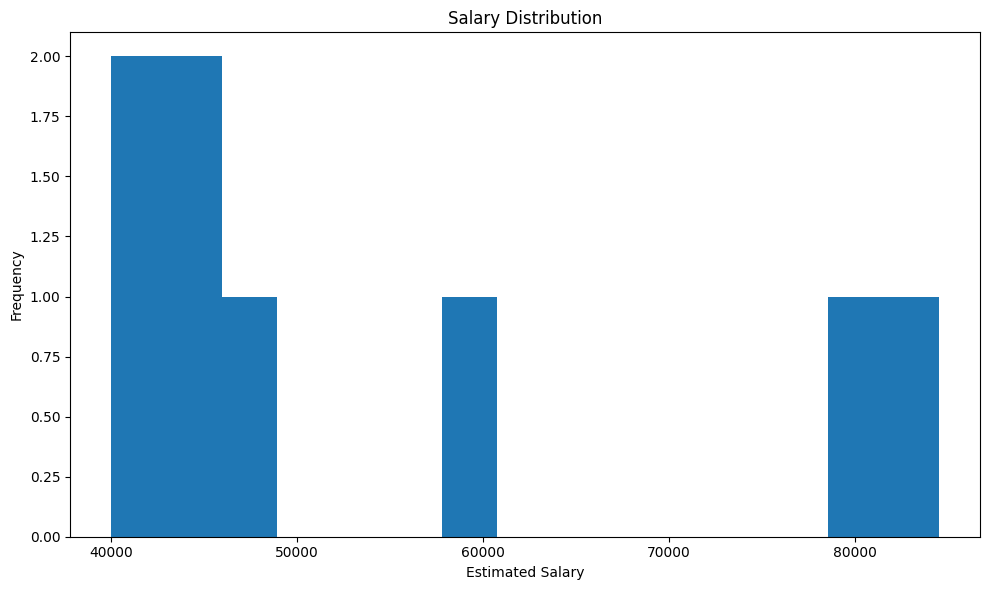

In [14]:
salary_data = df.loc[df["salary_valid"] == True, "salary_mid"].dropna()
plt.figure(figsize=(10, 6))
salary_data.plot(kind="hist", bins=15)
plt.title("Salary Distribution")
plt.xlabel("Estimated Salary")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../outputs/salary_histogram.png")
plt.show()

### Interpretation

Only a limited number of listings contained usable salary information, so the salary analysis is based on a smaller subset of the dataset.

This is a common issue in real-world job data, where salary fields are often missing or inconsistently formatted. A future improvement would be to standardize salary units more carefully and separate annual, monthly, and hourly values if present.

## Overall Findings

This project showed that job listing data can be collected, cleaned, stored, and analyzed through a simple but complete data pipeline.

### Key findings
- The extracted tags included both technical and descriptive keywords.
- Many job listings had incomplete or inconsistent location data.
- Fully remote roles represented the majority of the dataset.
- Python appeared more frequently than SQL, Excel, and Power BI in detected skill mentions.
- Salary information was available for only a limited subset of listings.

### What this means
The project successfully demonstrates an end-to-end workflow for web-based job market analysis. At the same time, it also highlights the challenges of working with real-world data, including missing values, inconsistent text fields, and noisy extracted tags.